# Project Utilities
Quick access to project utilities for testing.

In [1]:
# Configure Django
import os
import django

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "app.settings")

django.setup()

# Generate QR Code

## OpenLGU QR code

In [ ]:
# Load face image
import base64

face_str = None
PATH_TO_IMAGE = r"C:\Users\J4M3S\Desktop\MOSIP\OpenLGU-DIS_backend\residents\sample\citizen_3.jpg"
with open(PATH_TO_IMAGE, "rb") as img:
    face_str = base64.b64encode(img.read()).decode()

In [3]:
# Fill up demographic information
demographic_information = {
    "first_name" : "Mañuel Luis",
    "middle_name" : "y Molina",
    "last_name" : "Quezon",
    "suffix_name" : "",
    "date_of_birth" : "1878-08-19",
    "address" : "Baler, Tayabas, Philippines",
    "pcn" : "2092578314",
    "uin" : "3755189926",
    "face_image" : face_str
}

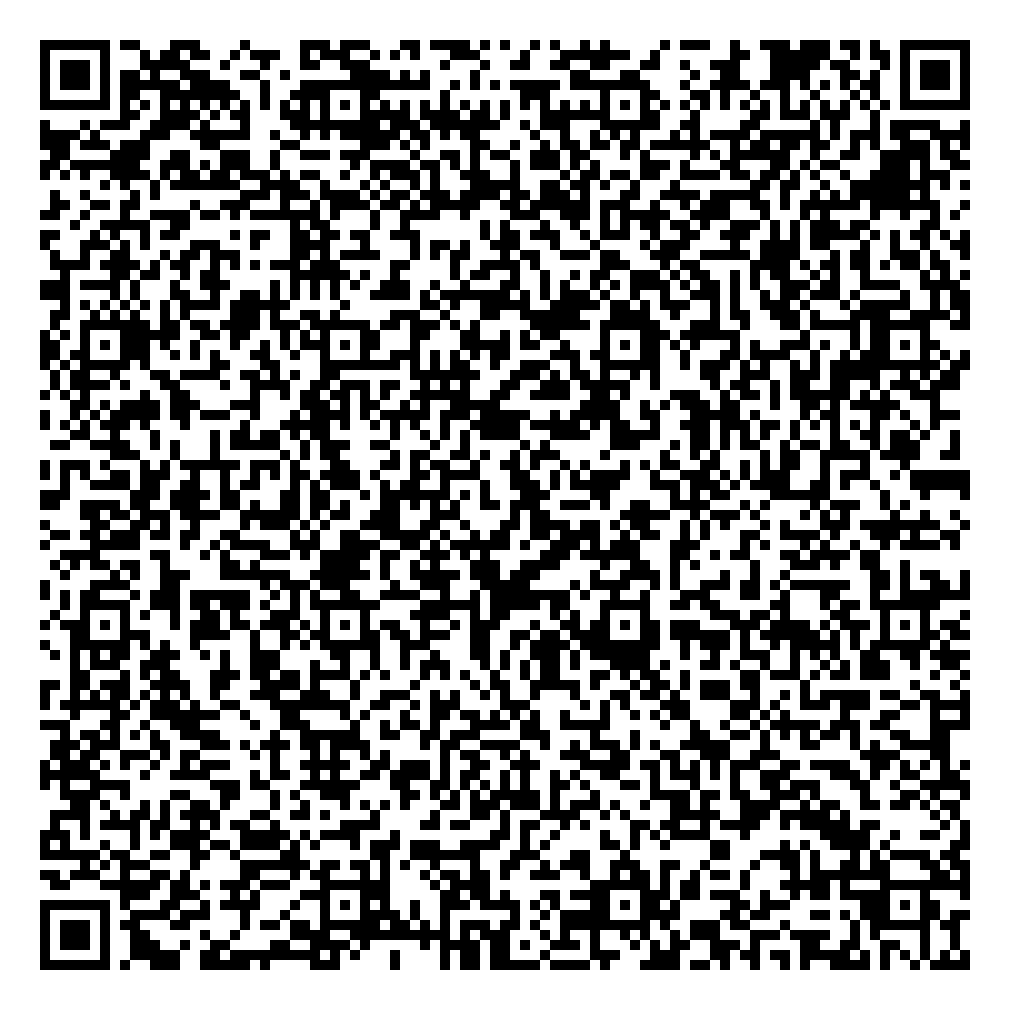

In [4]:
# Generate QR
from qr_manager.utils import generate_qr
from PIL import Image
from io import BytesIO

qr_bytes = generate_qr(**demographic_information)
img = Image.open(BytesIO(qr_bytes))
display(img)

## PhilSys Temporary QR Code

In [1]:
# Load face image

face_bytes = b''
PATH_TO_IMAGE = r"C:\Users\J4M3S\Desktop\MOSIP\OpenLGU-DIS_backend\residents\sample\citizen_3_compressed.jpg"
with open(PATH_TO_IMAGE, "rb") as img:
    face_bytes = img.read()

In [1]:
# Fill up demographic information
subject_biographics = {
    "s"  : "Male",
    "BF" : "[1,2]",
    "fn" : "X Æ A-12",
    "ln" : "Musk",
    "mn" : "Boucher",
    "sf" : "",
    "DOB" : "2020-05-01",
    "PCN" : "2184175105",
    "POB" : "Angeles City, Philippines"
}

claim_169 = {
    "d" : "2021-01-02",
    "i" : "PSA",
    "sb" : subject_biographics,
    "img" : b''
    # "img" : face_bytes
}

cwt = {
    1 : "PH",
    6 : "1609545227",
    8 : { 3 : "key" },
    169 : claim_169
}

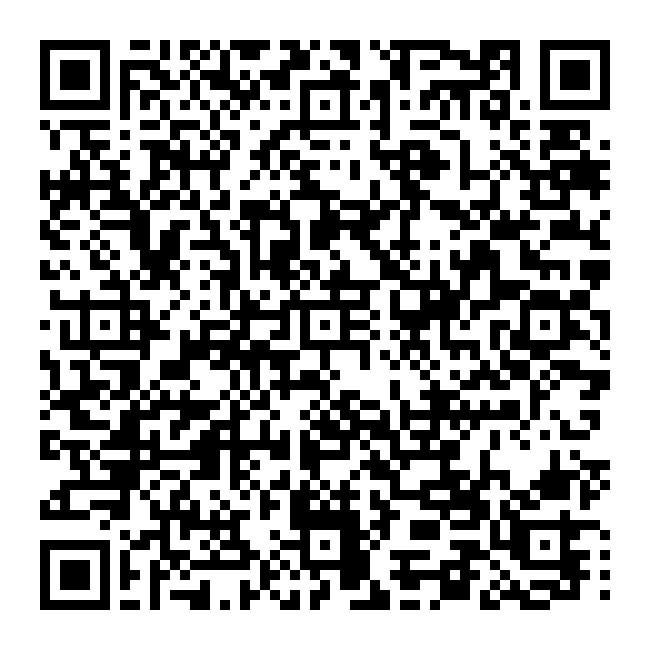

In [2]:
# Generate QR code
import cbor2
import base45
import qrcode

payload = cbor2.dumps(cwt)

cbtag = cbor2.CBORTag(
    18,
    [
        b"\xa1\x01'",
        {},
        payload,
        b''
    ]
)

b45 = base45.b45encode(cbor2.dumps(cbtag))

qr_data = b'PH1:' + b45

qr = qrcode.make(qr_data)
display(qr)

# Reading QR Code

## OpenLGU QR code

### Read QR code bytes

In [ ]:
from qr_manager import read_qr

### Read QR code image

In [ ]:
from qr_manager import read_qr_image
import base64

PATH_TO_FILE = r"C:\Users\J4M3S\Desktop\MOSIP\OpenLGU-DIS_backend\qr_manager\sample\quezon.png"

with open(PATH_TO_FILE, "rb") as file:
    image_bytes = file.read()

b64_image = base64.b64encode(image_bytes).decode()
result = read_qr_image(b64_image)
display(result)

# Face Compression

In [ ]:
# Load face image

face_bytes = b''
PATH_TO_IMAGE = r"C:\Users\J4M3S\Desktop\CS 198-199\Pictures\sample.jpg"
with open(PATH_TO_IMAGE, "rb") as img:
    face_bytes = img.read()

In [3]:
# Compress face
from qr_manager.utils import process_image
import base64

face_b64 = base64.b64encode(face_bytes).decode()
processed_image = process_image(face_b64)

Size of Original Image: 169041 bytes
Size of Compressed Image: 366 bytes


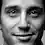

In [8]:
# Display results
from PIL import Image
from io import BytesIO

print(f"Size of Original Image: {len(face_bytes)} bytes")
print(f"Size of Compressed Image: {len(processed_image)} bytes")

img = Image.open(BytesIO(processed_image))
display(img)